In [1]:
!pip install numpy pandas matplotlib torch torchvision

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

### Task 1 — Convolution Mechanics: Filters and Shapes

**Part A — Handcrafted filters.**

In [3]:
# Task 1A — Handcrafted filters

tf = transforms.Compose([
    transforms.ToTensor()
])

cifar = datasets.CIFAR10(root="./data", train=True, download=True, transform=tf)

img, label = cifar[0]
img_batch = img.unsqueeze(0)   # (1, 3, 32, 32)

print("Image batch shape:", img_batch.shape)
print("Label:", label)

Image batch shape: torch.Size([1, 3, 32, 32])
Label: 6


In [4]:
# Create handcrafted filters

vertical_filter = torch.tensor([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=torch.float32)

horizontal_filter = vertical_filter.T

blur_filter = torch.ones((3, 3), dtype=torch.float32) / 9

In [5]:
def make_filter_conv(filter_2d):
    conv = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)
    
    with torch.no_grad():
        # Same 3x3 filter is applied to all RGB channels
        conv.weight[:] = filter_2d.view(1, 1, 3, 3).repeat(1, 3, 1, 1)
    
    return conv

In [6]:
vertical_conv = make_filter_conv(vertical_filter)
horizontal_conv = make_filter_conv(horizontal_filter)
blur_conv = make_filter_conv(blur_filter)

with torch.no_grad():
    vertical_out = vertical_conv(img_batch)
    horizontal_out = horizontal_conv(img_batch)
    blur_out = blur_conv(img_batch)

print("Vertical output shape:", vertical_out.shape)
print("Horizontal output shape:", horizontal_out.shape)
print("Blur output shape:", blur_out.shape)

Vertical output shape: torch.Size([1, 1, 32, 32])
Horizontal output shape: torch.Size([1, 1, 32, 32])
Blur output shape: torch.Size([1, 1, 32, 32])


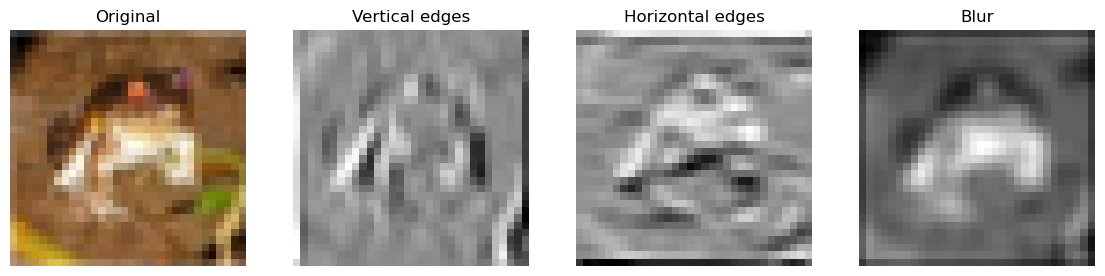

In [7]:
# Visualise original + filtered outputs

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(vertical_out.squeeze().numpy(), cmap="gray")
plt.title("Vertical edges")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(horizontal_out.squeeze().numpy(), cmap="gray")
plt.title("Horizontal edges")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(blur_out.squeeze().numpy(), cmap="gray")
plt.title("Blur")
plt.axis("off")

plt.show()

### Task 1A — Handcrafted Filters

The vertical edge filter highlights vertical changes in the image, such as object borders and strong left-to-right intensity differences. In the output, the edges around the frog become more visible while smoother regions remain darker.

The horizontal edge filter highlights horizontal changes in pixel intensity. It detects top-to-bottom transitions and emphasizes horizontal structures and contours in the image.

The blur filter smooths the image by averaging neighbouring pixel values. As a result, sharp edges and fine details become softer and less visible. The overall image looks smoother and less noisy.

These results demonstrate how convolution filters can extract different types of visual features from the same image.

**Part B — Shape tracking.**

In [8]:
# Task 1B — Shape tracking

class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

tiny_model = TinyCNN()

x = torch.randn(8, 3, 32, 32)

print("Input:", x.shape)

x1 = tiny_model.conv1(x)
print("After conv1:", x1.shape)

x2 = tiny_model.pool1(x1)
print("After pool1:", x2.shape)

x3 = tiny_model.conv2(x2)
print("After conv2:", x3.shape)

x4 = tiny_model.pool2(x3)
print("After pool2:", x4.shape)

Input: torch.Size([8, 3, 32, 32])
After conv1: torch.Size([8, 16, 32, 32])
After pool1: torch.Size([8, 16, 16, 16])
After conv2: torch.Size([8, 32, 16, 16])
After pool2: torch.Size([8, 32, 8, 8])


### Task 1B — Shape Tracking

| Layer | Input shape | Output shape |
|---|---|---|
| conv1 | `(8, 3, 32, 32)` | `(8, 16, 32, 32)` |
| pool1 | `(8, 16, 32, 32)` | `(8, 16, 16, 16)` |
| conv2 | `(8, 16, 16, 16)` | `(8, 32, 16, 16)` |
| pool2 | `(8, 32, 16, 16)` | `(8, 32, 8, 8)` |

The convolution layers keep the height and width the same because they use `kernel_size=3` with `padding=1`. However, they change the number of channels. `conv1` changes the input from 3 channels to 16 feature maps, and `conv2` changes 16 feature maps to 32 feature maps.

The max pooling layers reduce the spatial size by half. Therefore, after `pool1`, the image size changes from 32×32 to 16×16, and after `pool2`, it changes from 16×16 to 8×8.

### Task 2 — Train a Small CNN on CIFAR-10

In [9]:
# Task 2 — Data loading for CIFAR-10

basic_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_set = datasets.CIFAR10(root="./data", train=True, download=True, transform=basic_tf)
val_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=basic_tf)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False)

classes = train_set.classes

print("Train size:", len(train_set))
print("Validation size:", len(val_set))
print("Classes:", classes)

Train size: 50000
Validation size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [11]:
# Task 2 — CNN model

class CIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),   # 32x32 -> 16x16

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)    # 16x16 -> 8x8
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
model = CIFAR10CNN().to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 1117354
Trainable parameters: 1117354


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [14]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 15

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}"
    )

Epoch 01/15 | Train loss: 1.4544 | Train acc: 0.4746 | Val loss: 1.0514 | Val acc: 0.6194
Epoch 02/15 | Train loss: 0.9998 | Train acc: 0.6437 | Val loss: 0.9178 | Val acc: 0.6739
Epoch 03/15 | Train loss: 0.8378 | Train acc: 0.7042 | Val loss: 0.7618 | Val acc: 0.7320
Epoch 04/15 | Train loss: 0.7369 | Train acc: 0.7409 | Val loss: 0.8036 | Val acc: 0.7275
Epoch 05/15 | Train loss: 0.6743 | Train acc: 0.7648 | Val loss: 0.7925 | Val acc: 0.7367
Epoch 06/15 | Train loss: 0.6131 | Train acc: 0.7844 | Val loss: 0.7009 | Val acc: 0.7546
Epoch 07/15 | Train loss: 0.5708 | Train acc: 0.7981 | Val loss: 0.6424 | Val acc: 0.7765
Epoch 08/15 | Train loss: 0.5319 | Train acc: 0.8119 | Val loss: 0.6450 | Val acc: 0.7805
Epoch 09/15 | Train loss: 0.4826 | Train acc: 0.8288 | Val loss: 0.6188 | Val acc: 0.7956
Epoch 10/15 | Train loss: 0.4467 | Train acc: 0.8401 | Val loss: 0.6208 | Val acc: 0.7962
Epoch 11/15 | Train loss: 0.4144 | Train acc: 0.8523 | Val loss: 0.5962 | Val acc: 0.8015
Epoch 12/1

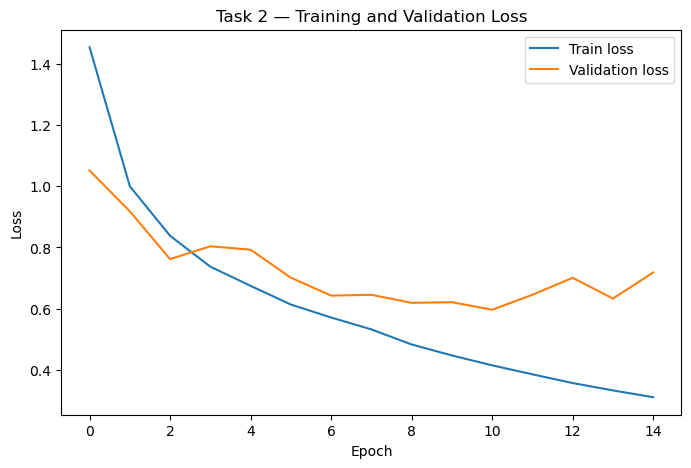

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 2 — Training and Validation Loss")
plt.legend()
plt.show()

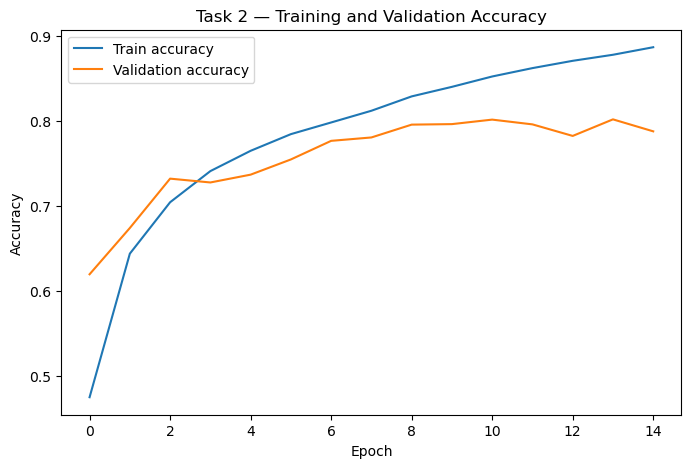

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train accuracy")
plt.plot(val_accs, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Task 2 — Training and Validation Accuracy")
plt.legend()
plt.show()

### Task 2 — CNN Training Results and Analysis

In this task, I trained a convolutional neural network on the CIFAR-10 dataset for 15 epochs using the Adam optimizer and CrossEntropyLoss. The model contained approximately 1.1 million trainable parameters.

The training results show that the network successfully learned meaningful visual features from the images. The training accuracy increased steadily from 47.46% in the first epoch to 88.67% in the final epoch. At the same time, the training loss continuously decreased, which indicates that the model was learning effectively during optimization.

The validation accuracy also improved significantly during training. It started at 61.94% and reached a best value of approximately 80.18%. This is higher than the expected 70–75% accuracy mentioned in the lab instructions, which shows that the CNN architecture performed well on CIFAR-10.

From the loss graph, the training loss consistently decreased throughout training, while the validation loss decreased at first and later fluctuated slightly. This behaviour suggests that the model began to slightly overfit after later epochs because the training performance kept improving while the validation performance stopped improving consistently.

The accuracy graph also supports this observation. The training accuracy continued increasing across all epochs, while the validation accuracy stabilised around 79–80%. Even though a small train-validation gap appeared, the model still generalised reasonably well to unseen data.

Overall, the experiment demonstrates that convolutional neural networks are highly effective for image classification tasks because they can automatically learn hierarchical visual features such as edges, textures, shapes, and object patterns from image data.

### Task 3 — Data Augmentation

In [18]:
# Task 3 — Data augmentation transforms

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [19]:
# Augmented datasets

train_set_aug = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_tf
)

val_set_aug = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=val_tf
)

train_loader_aug = DataLoader(train_set_aug, batch_size=128, shuffle=True)
val_loader_aug = DataLoader(val_set_aug, batch_size=128, shuffle=False)

print("Augmented training size:", len(train_set_aug))
print("Validation size:", len(val_set_aug))

Augmented training size: 50000
Validation size: 10000


In [20]:
# New model for augmentation experiment

model_aug = CIFAR10CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.parameters(), lr=1e-3)

In [21]:
epochs = 15

train_losses_aug = []
train_accs_aug = []
val_losses_aug = []
val_accs_aug = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        model_aug,
        train_loader_aug,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model_aug,
        val_loader_aug,
        criterion,
        device
    )

    train_losses_aug.append(train_loss)
    train_accs_aug.append(train_acc)
    val_losses_aug.append(val_loss)
    val_accs_aug.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.4f}"
    )

Epoch 01/15 | Train loss: 1.6213 | Train acc: 0.4067 | Val loss: 1.2102 | Val acc: 0.5600
Epoch 02/15 | Train loss: 1.2062 | Train acc: 0.5655 | Val loss: 0.9537 | Val acc: 0.6549
Epoch 03/15 | Train loss: 1.0497 | Train acc: 0.6244 | Val loss: 0.8532 | Val acc: 0.6963
Epoch 04/15 | Train loss: 0.9554 | Train acc: 0.6641 | Val loss: 0.7498 | Val acc: 0.7353
Epoch 05/15 | Train loss: 0.9070 | Train acc: 0.6789 | Val loss: 0.7992 | Val acc: 0.7174
Epoch 06/15 | Train loss: 0.8641 | Train acc: 0.6978 | Val loss: 0.7342 | Val acc: 0.7404
Epoch 07/15 | Train loss: 0.8256 | Train acc: 0.7101 | Val loss: 0.6974 | Val acc: 0.7584
Epoch 08/15 | Train loss: 0.7940 | Train acc: 0.7221 | Val loss: 0.7780 | Val acc: 0.7288
Epoch 09/15 | Train loss: 0.7659 | Train acc: 0.7318 | Val loss: 0.6645 | Val acc: 0.7753
Epoch 10/15 | Train loss: 0.7444 | Train acc: 0.7421 | Val loss: 0.6466 | Val acc: 0.7767
Epoch 11/15 | Train loss: 0.7205 | Train acc: 0.7501 | Val loss: 0.6215 | Val acc: 0.7861
Epoch 12/1

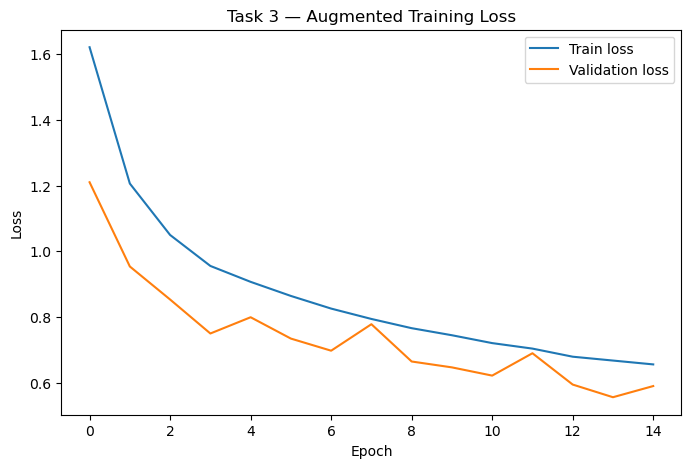

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_aug, label="Train loss")
plt.plot(val_losses_aug, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 3 — Augmented Training Loss")
plt.legend()

plt.show()

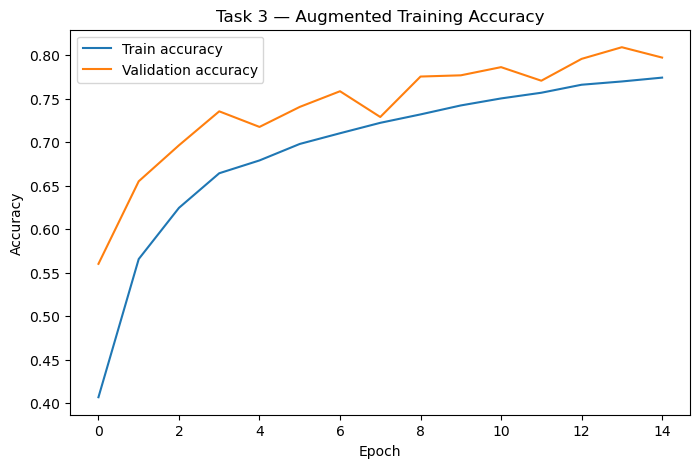

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(train_accs_aug, label="Train accuracy")
plt.plot(val_accs_aug, label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Task 3 — Augmented Training Accuracy")
plt.legend()

plt.show()

In [24]:
# Compare Task 2 and Task 3

task2_best = max(val_accs)
task3_best = max(val_accs_aug)

task2_gap = max(train_accs) - max(val_accs)
task3_gap = max(train_accs_aug) - max(val_accs_aug)

print("| Run | Best val accuracy | Train/val gap |")
print("|---|---|---|")
print(f"| Task 2 (no augmentation) | {task2_best:.4f} | {task2_gap:.4f} |")
print(f"| Task 3 (with augmentation) | {task3_best:.4f} | {task3_gap:.4f} |")

| Run | Best val accuracy | Train/val gap |
|---|---|---|
| Task 2 (no augmentation) | 0.8018 | 0.0849 |
| Task 3 (with augmentation) | 0.8090 | -0.0349 |


### Task 3 — Data Augmentation Results and Analysis

In this task, I trained the same CNN architecture again, but this time I used data augmentation on the training set. The augmentation pipeline included random cropping, random horizontal flipping, and small brightness/contrast changes. The validation set was kept unchanged so that the model was evaluated on clean images.

The augmented model reached a best validation accuracy of **80.90%**, while the model without augmentation reached **80.18%**. This shows a small improvement in validation performance.

| Run | Best val accuracy | Train/val gap |
|---|---:|---:|
| Task 2 (no augmentation) | 0.8018 | 0.0849 |
| Task 3 (with augmentation) | 0.8090 | -0.0349 |

The main difference is visible in the train/validation gap. Without augmentation, the training accuracy became much higher than the validation accuracy, which suggests slight overfitting. With augmentation, the training accuracy stayed lower because the model saw randomly changed versions of the images during training. This made the training task harder, but it helped the model generalise better.

The loss graph also supports this result. The training loss decreased more slowly with augmentation, while the validation loss stayed relatively stable and reached a lower value near the end. The accuracy graph shows that validation accuracy was often higher than training accuracy, which is normal with augmentation because the training images are made more difficult by random transformations.

Overall, data augmentation improved generalisation. Even though the improvement in best validation accuracy was small, the model became less overfitted and more robust to small changes in the input images.